In [7]:
# 1 - Mount Drive and load playlist data

from google.colab import drive
drive.mount('/content/drive')

import os
from pathlib import Path
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score
)
import matplotlib.pyplot as plt
import json
import warnings
warnings.filterwarnings('ignore')

# Paths aligned with pretrain notebook
ROOT = Path("/content/drive/My Drive/mbti-tune")
DATA_PATH = ROOT / "data"
PROCESSED_PATH = DATA_PATH / "processed"
MODEL_PATH = ROOT / "models"
os.makedirs(MODEL_PATH, exist_ok=True)

print("ROOT:", ROOT)
print("DATA_PATH:", DATA_PATH)
print("PROCESSED_PATH:", PROCESSED_PATH)
print("MODEL_PATH:", MODEL_PATH)

# Load playlist data (your current playlist dataset)
playlist_csv = PROCESSED_PATH / "playlist_data_from_mbti_playlists.csv"
df = pd.read_csv(playlist_csv)
print(f"\n✅ Loaded {len(df)} playlists from {playlist_csv}")

print("\n📊 Personality distribution:")
print(df["mbti"].value_counts())

print("\n📊 Dimension balance:")
for dim in ["E", "S", "T", "J"]:
    print(f"   {dim}: {df[dim].mean()*100:.1f}%")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
ROOT: /content/drive/My Drive/mbti-tune
DATA_PATH: /content/drive/My Drive/mbti-tune/data
PROCESSED_PATH: /content/drive/My Drive/mbti-tune/data/processed
MODEL_PATH: /content/drive/My Drive/mbti-tune/models

✅ Loaded 4201 playlists from /content/drive/My Drive/mbti-tune/data/processed/playlist_data_from_mbti_playlists.csv

📊 Personality distribution:
mbti
INTJ    307
ESTP    306
INFJ    304
ENTP    303
ENTJ    303
ENFP    302
ENFJ    302
ISTP    300
INTP    299
INFP    295
ISFP    295
ESFP    231
ISFJ    221
ISTJ    196
ESTJ    122
ESFJ    115
Name: count, dtype: int64

📊 Dimension balance:
   E: 47.2%
   S: 42.5%
   T: 50.8%
   J: 44.5%


In [8]:
# 2 - Load pretrain features (42) and align playlist data

# Load the exact feature list used during autoencoder pretraining
pretrain_features_path = MODEL_PATH / "pretrain_features.json"
with open(pretrain_features_path, "r") as f:
    pretrain_features = json.load(f)

print(f"Autoencoder expects {len(pretrain_features)} features")

# Ensure all pretrain features exist in playlist dataframe
for feat in pretrain_features:
    if feat not in df.columns:
        df[feat] = 0.0  # missing features filled with zeros

feature_cols = pretrain_features
print(f"Playlist classifier using {len(feature_cols)} features")

# Ensure numeric and handle missing
df[feature_cols] = df[feature_cols].apply(pd.to_numeric, errors="coerce")
df[feature_cols] = df[feature_cols].fillna(df[feature_cols].median())

# Build X and y
X = df[feature_cols].values.astype(np.float32)
y = df[["E", "S", "T", "J"]].values.astype(np.float32)

print(f"\nX shape: {X.shape}")
print(f"y shape: {y.shape}")

# Train/val/test split (70/15/15), stratified by mbti
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=df["mbti"]
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42
)

print("\n📊 Split sizes:")
print(f"   Train: {len(X_train)}")
print(f"   Val:   {len(X_val)}")
print(f"   Test:  {len(X_test)}")

# Normalize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# Convert to tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

print("\n✅ Data ready for training")


Autoencoder expects 42 features
Playlist classifier using 42 features

X shape: (4201, 42)
y shape: (4201, 4)

📊 Split sizes:
   Train: 2940
   Val:   630
   Test:  631

✅ Data ready for training


In [9]:
# 3 - Transfer learning architecture (autoencoder encoder + classifier)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

class AutoencoderEncoder(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Linear(64, 16)
        )
    def forward(self, x):
        return self.encoder(x)

class MBTINetwork(nn.Module):
    def __init__(self, input_dim, pretrained_path=None):
        super().__init__()
        self.music_encoder = AutoencoderEncoder(input_dim=input_dim)

        if pretrained_path is not None:
            state = torch.load(pretrained_path, map_location=device)
            # state was saved as model.encoder.state_dict() in pretrain notebook
            # so keys already start with '0.', '1.', etc. inside encoder
            self.music_encoder.encoder.load_state_dict(state, strict=True)
            for p in self.music_encoder.parameters():
                p.requires_grad = False
            print(f"✅ Loaded pretrained encoder from {pretrained_path}")

        self.classifier = nn.Sequential(
            nn.Linear(16, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Linear(32, 4)
        )

    def forward(self, x):
        z = self.music_encoder(x)
        out = self.classifier(z)
        return out

PRETRAIN_PATH = MODEL_PATH / "encoder_114k_weights.pth"
model = MBTINetwork(input_dim=len(feature_cols), pretrained_path=PRETRAIN_PATH).to(device)


Using device: cpu
✅ Loaded pretrained encoder from /content/drive/My Drive/mbti-tune/models/encoder_114k_weights.pth


In [10]:
# 4 - Class weights for imbalance and loss function

def calculate_class_weights(y_tensor):
    y_np = y_tensor.numpy()
    weights = []
    for i in range(4):
        n_pos = y_np[:, i].sum()
        n_neg = len(y_np) - n_pos
        weight = (n_neg / n_pos) if n_pos > 0 else 1.0
        weights.append(weight)
    return torch.tensor(weights, device=device, dtype=torch.float32)

pos_weights = calculate_class_weights(y_train)
print("\nPositive class weights (E,S,T,J):")
print(f"  E: {pos_weights[0]:.3f}")
print(f"  S: {pos_weights[1]:.3f}")
print(f"  T: {pos_weights[2]:.3f}")
print(f"  J: {pos_weights[3]:.3f}")

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weights)



Positive class weights (E,S,T,J):
  E: 1.118
  S: 1.350
  T: 0.968
  J: 1.246


In [11]:
# 5 - Training loop with fine-tuning

def train_model(model, X_train, y_train, X_val, y_val,
                epochs=200, batch_size=32, lr=1e-3):
    train_ds = TensorDataset(X_train, y_train)
    val_ds = TensorDataset(X_val, y_val)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size)

    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=15, factor=0.5)

    train_losses, val_losses, val_accs = [], [], []
    best_val_loss = float("inf")

    for epoch in range(epochs):
        # Unfreeze encoder after 50 epochs
        if epoch == 50:
            for p in model.music_encoder.parameters():
                p.requires_grad = True
            print("\n🔥 Unfreezing encoder for fine-tuning...")

        model.train()
        train_loss = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        train_loss /= len(train_loader)

        model.eval()
        val_loss = 0.0
        all_preds, all_targets = [], []
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                logits = model(xb)
                loss = criterion(logits, yb)
                val_loss += loss.item()
                all_preds.append(torch.sigmoid(logits).cpu())
                all_targets.append(yb.cpu())

        val_loss /= len(val_loader)
        all_preds = torch.cat(all_preds)
        all_targets = torch.cat(all_targets)
        acc = (torch.abs(all_preds - all_targets) < 0.15).float().mean().item()

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        val_accs.append(acc)
        scheduler.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), MODEL_PATH / "playlist_classifier_best.pth")

        if (epoch + 1) % 25 == 0:
            print(f"Epoch {epoch+1:3d}/{epochs} | "
                  f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Acc@15%: {acc:.2%}")

    return train_losses, val_losses, val_accs

train_losses, val_losses, val_accuracies = train_model(model, X_train, y_train, X_val, y_val)


Epoch  25/200 | Train Loss: 0.6905 | Val Loss: 0.6733 | Acc@15%: 0.40%
Epoch  50/200 | Train Loss: 0.6856 | Val Loss: 0.6694 | Acc@15%: 0.67%

🔥 Unfreezing encoder for fine-tuning...
Epoch  75/200 | Train Loss: 0.6398 | Val Loss: 0.6470 | Acc@15%: 8.33%
Epoch 100/200 | Train Loss: 0.6258 | Val Loss: 0.6466 | Acc@15%: 8.53%
Epoch 125/200 | Train Loss: 0.5961 | Val Loss: 0.6428 | Acc@15%: 11.51%
Epoch 150/200 | Train Loss: 0.5879 | Val Loss: 0.6456 | Acc@15%: 13.17%
Epoch 175/200 | Train Loss: 0.5876 | Val Loss: 0.6466 | Acc@15%: 14.48%
Epoch 200/200 | Train Loss: 0.5804 | Val Loss: 0.6473 | Acc@15%: 15.36%


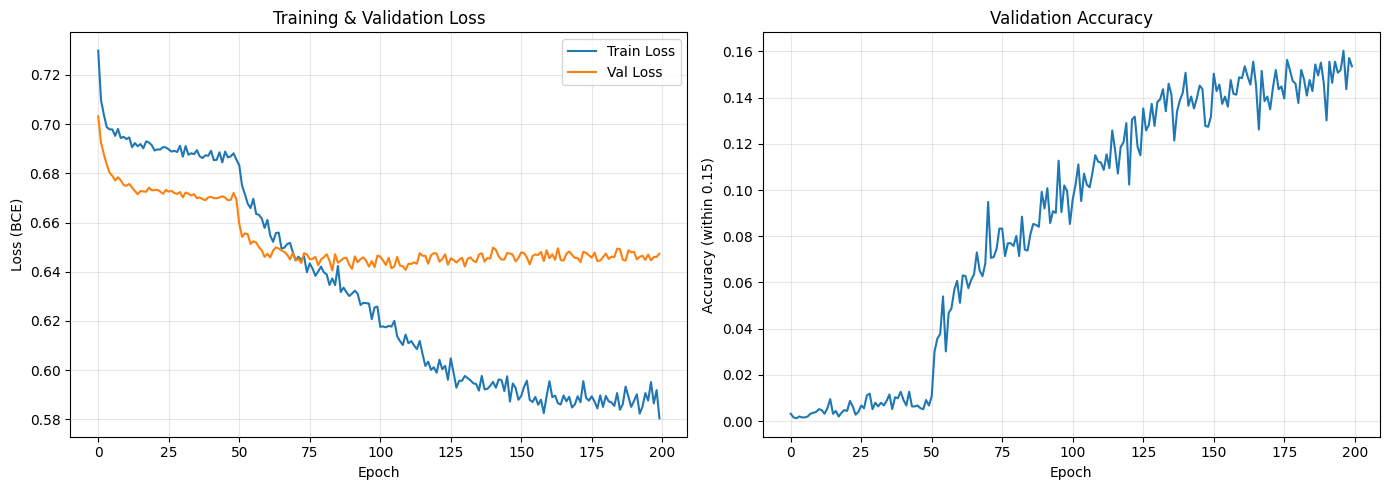

Final validation accuracy: 15.36%


In [12]:
# 6 - Visualize training progress

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(train_losses, label="Train Loss")
axes[0].plot(val_losses, label="Val Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss (BCE)")
axes[0].set_title("Training & Validation Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(val_accuracies)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy (within 0.15)")
axes[1].set_title("Validation Accuracy")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Final validation accuracy: {val_accuracies[-1]:.2%}")


In [13]:
# 7 - Test set evaluation (regression + classification metrics)

BEST_MODEL_PATH = MODEL_PATH / "playlist_classifier_best.pth"
model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device))

model.eval()
with torch.no_grad():
    X_test_device = X_test.to(device)
    logits = model(X_test_device)
    predictions = torch.sigmoid(logits).cpu().numpy()
    targets = y_test.numpy()

dim_names = ["Extraversion (E)", "Sensing/Intuition (S)", "Thinking (T)", "Judging (J)"]
dim_letters = ["E", "S", "T", "J"]

print("="*60)
print("TEST SET RESULTS")
print("="*60)

results = {}
for i, (name, letter) in enumerate(zip(dim_names, dim_letters)):
    mae = mean_absolute_error(targets[:, i], predictions[:, i])
    r2 = r2_score(targets[:, i], predictions[:, i])
    results[letter] = {"mae": mae, "r2": r2}
    print(f"\n{name} ({letter}):")
    print(f"  MAE:  {mae:.3f} ({mae*100:.1f}% avg error)")
    print(f"  R²:   {r2:.3f}")

overall_mae = mean_absolute_error(targets.flatten(), predictions.flatten())
acc15 = (np.abs(predictions - targets) < 0.15).mean()
acc10 = (np.abs(predictions - targets) < 0.10).mean()

print("\n" + "="*60)
print("OVERALL METRICS")
print("="*60)
print(f"Overall MAE: {overall_mae:.3f} ({overall_mae*100:.1f}%)")
print(f"Accuracy (within 15%): {acc15*100:.2f}%")
print(f"Accuracy (within 10%): {acc10*100:.2f}%")

print("\n" + "="*60)
print("CLASSIFICATION METRICS (Threshold = 0.5)")
print("="*60)

binary_preds = (predictions > 0.5).astype(int)
binary_targets = (targets > 0.5).astype(int)

accs, precs, recs, f1s = [], [], [], []

for i, (name, letter) in enumerate(zip(dim_names, dim_letters)):
    acc = accuracy_score(binary_targets[:, i], binary_preds[:, i])
    prec = precision_score(binary_targets[:, i], binary_preds[:, i], zero_division=0)
    rec = recall_score(binary_targets[:, i], binary_preds[:, i], zero_division=0)
    f1 = f1_score(binary_targets[:, i], binary_preds[:, i], zero_division=0)

    accs.append(acc); precs.append(prec); recs.append(rec); f1s.append(f1)

    print(f"\n{name} ({letter}):")
    print(f"  Accuracy:  {acc:.3f}")
    print(f"  Precision: {prec:.3f}")
    print(f"  Recall:    {rec:.3f}")
    print(f"  F1-Score:  {f1:.3f}")

macro_acc = accuracy_score(binary_targets.flatten(), binary_preds.flatten())
macro_prec = precision_score(binary_targets.flatten(), binary_preds.flatten(), zero_division=0)
macro_rec = recall_score(binary_targets.flatten(), binary_preds.flatten(), zero_division=0)
macro_f1 = f1_score(binary_targets.flatten(), binary_preds.flatten(), zero_division=0)

print("\n" + "="*60)
print("MACRO-AVERAGED CLASSIFICATION METRICS")
print("="*60)
print(f"Macro Accuracy:  {macro_acc:.3f}")
print(f"Macro Precision:{macro_prec:.3f}")
print(f"Macro Recall:   {macro_rec:.3f}")
print(f"Macro F1-Score: {macro_f1:.3f}")


TEST SET RESULTS

Extraversion (E) (E):
  MAE:  0.364 (36.4% avg error)
  R²:   0.274

Sensing/Intuition (S) (S):
  MAE:  0.464 (46.4% avg error)
  R²:   0.043

Thinking (T) (T):
  MAE:  0.397 (39.7% avg error)
  R²:   0.170

Judging (J) (J):
  MAE:  0.451 (45.1% avg error)
  R²:   0.093

OVERALL METRICS
Overall MAE: 0.419 (41.9%)
Accuracy (within 15%): 7.13%
Accuracy (within 10%): 1.90%

CLASSIFICATION METRICS (Threshold = 0.5)

Extraversion (E) (E):
  Accuracy:  0.735
  Precision: 0.681
  Recall:    0.779
  F1-Score:  0.727

Sensing/Intuition (S) (S):
  Accuracy:  0.613
  Precision: 0.554
  Recall:    0.509
  F1-Score:  0.531

Thinking (T) (T):
  Accuracy:  0.681
  Precision: 0.701
  Recall:    0.682
  F1-Score:  0.691

Judging (J) (J):
  Accuracy:  0.628
  Precision: 0.586
  Recall:    0.617
  F1-Score:  0.601

MACRO-AVERAGED CLASSIFICATION METRICS
Macro Accuracy:  0.664
Macro Precision:0.636
Macro Recall:   0.650
Macro F1-Score: 0.643


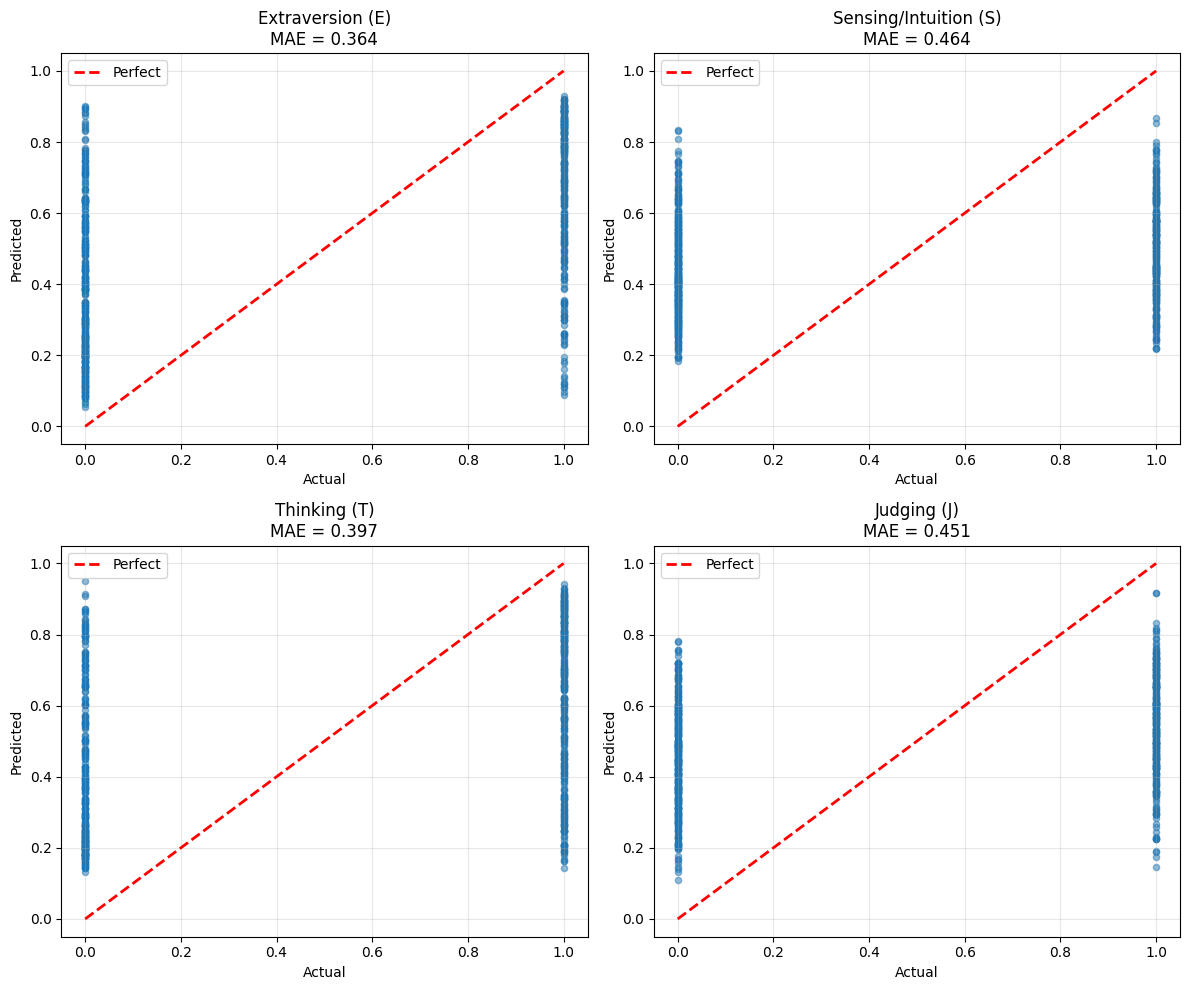

In [14]:
# 8 - Predictions vs actual scatter plots

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for i, (name, ax) in enumerate(zip(dim_names, axes.flatten())):
    ax.scatter(targets[:, i], predictions[:, i], alpha=0.5, s=20)
    ax.plot([0, 1], [0, 1], "r--", linewidth=2, label="Perfect")
    ax.set_xlabel("Actual")
    ax.set_ylabel("Predicted")
    ax.set_title(f"{name}\nMAE = {results[dim_letters[i]]['mae']:.3f}")
    ax.legend()
    ax.grid(alpha=0.3)
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 1.05)

plt.tight_layout()
plt.show()


In [15]:
# 9 - SNAP: self-normalized auxiliary prediction

def snap_playlist_mbti(feature_dict):
    df_input = pd.DataFrame([feature_dict])[feature_cols]
    X_scaled = scaler.transform(df_input)
    X_tensor = torch.tensor(X_scaled, dtype=torch.float32).to(device)

    model.eval()
    with torch.no_grad():
        raw = torch.sigmoid(model(X_tensor)).cpu().numpy()[0]

    snap_norm = raw / raw.sum()
    snap_pct = snap_norm * 100

    return {
        "E_snap": round(snap_pct[0], 2),
        "S_snap": round(snap_pct[1], 2),
        "T_snap": round(snap_pct[2], 2),
        "J_snap": round(snap_pct[3], 2)
    }

print("SNAP function ready.")


SNAP function ready.


In [16]:
# 10 - Prediction + SNAP visualizations (radar + bars)

def predict_playlist_mbti(feature_dict):
    df_input = pd.DataFrame([feature_dict])[feature_cols]
    X_scaled = scaler.transform(df_input)
    X_tensor = torch.tensor(X_scaled, dtype=torch.float32).to(device)

    model.eval()
    with torch.no_grad():
        raw = torch.sigmoid(model(X_tensor)).cpu().numpy()[0] * 100

    return {
        "E": round(raw[0], 2),
        "S": round(raw[1], 2),
        "T": round(raw[2], 2),
        "J": round(raw[3], 2)
    }

def plot_mbti_radar(raw_dict, snap_dict, title="MBTI Radar Comparison"):
    labels = ["E", "S", "T", "J"]
    raw_vals = np.array([raw_dict[k] for k in labels])
    snap_vals = np.array([snap_dict[k + "_snap"] for k in labels])

    angles = np.linspace(0, 2*np.pi, len(labels), endpoint=False)
    raw_vals = np.concatenate((raw_vals, [raw_vals[0]]))
    snap_vals = np.concatenate((snap_vals, [snap_vals[0]]))
    angles = np.concatenate((angles, [angles[0]]))

    plt.figure(figsize=(6, 6))
    ax = plt.subplot(111, polar=True)

    ax.plot(angles, raw_vals, "o-", linewidth=2, label="Raw %")
    ax.fill(angles, raw_vals, alpha=0.25)

    ax.plot(angles, snap_vals, "o-", linewidth=2, label="SNAP %")
    ax.fill(angles, snap_vals, alpha=0.25)

    ax.set_thetagrids(angles[:-1] * 180/np.pi, labels)
    ax.set_title(title)
    ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
    plt.show()

def plot_mbti_bars(raw_dict, snap_dict):
    labels = ["E", "S", "T", "J"]
    raw_vals = [raw_dict[k] for k in labels]
    snap_vals = [snap_dict[k + "_snap"] for k in labels]

    x = np.arange(len(labels))
    width = 0.35

    plt.figure(figsize=(8, 5))
    plt.bar(x - width/2, raw_vals, width, label="Raw %")
    plt.bar(x + width/2, snap_vals, width, label="SNAP %")
    plt.xticks(x, labels)
    plt.ylabel("Percentage")
    plt.title("Raw vs SNAP MBTI Percentages")
    plt.legend()
    plt.ylim(0, 100)
    plt.show()

print("Prediction + SNAP visualizations ready.")


Prediction + SNAP visualizations ready.


In [17]:
# 11 - Prediction distribution + permutation feature importance

from sklearn.inspection import permutation_importance

def plot_prediction_distribution():
    model.eval()
    with torch.no_grad():
        preds = torch.sigmoid(model(X_test.to(device))).cpu().numpy() * 100

    plt.figure(figsize=(12, 6))
    labels = ["E", "S", "T", "J"]
    for i in range(4):
        plt.hist(preds[:, i], bins=20, alpha=0.6, label=labels[i])
    plt.title("Distribution of MBTI Predictions (Test Set)")
    plt.xlabel("Percentage")
    plt.ylabel("Frequency")
    plt.legend()
    plt.show()

def compute_feature_importance():
    class TorchWrapper:
        def __init__(self, model):
            self.model = model
        def predict(self, X):
            X_tensor = torch.tensor(X, dtype=torch.float32).to(device)
            with torch.no_grad():
                return torch.sigmoid(self.model(X_tensor)).cpu().numpy()

    wrapper = TorchWrapper(model)

    result = permutation_importance(
        wrapper,
        X_test.numpy(),
        y_test.numpy(),
        n_repeats=10,
        random_state=42
    )

    importances = result.importances_mean
    sorted_idx = np.argsort(importances)[::-1]

    plt.figure(figsize=(10, 12))
    plt.barh(np.array(feature_cols)[sorted_idx], importances[sorted_idx])
    plt.title("Permutation Feature Importance")
    plt.xlabel("Importance")
    plt.gca().invert_yaxis()
    plt.show()

print("Prediction distribution + feature importance ready.")


Prediction distribution + feature importance ready.


Initializing KernelExplainer...


  0%|          | 0/5 [00:00<?, ?it/s]


📊 Feature Impact for: Extraversion (E)


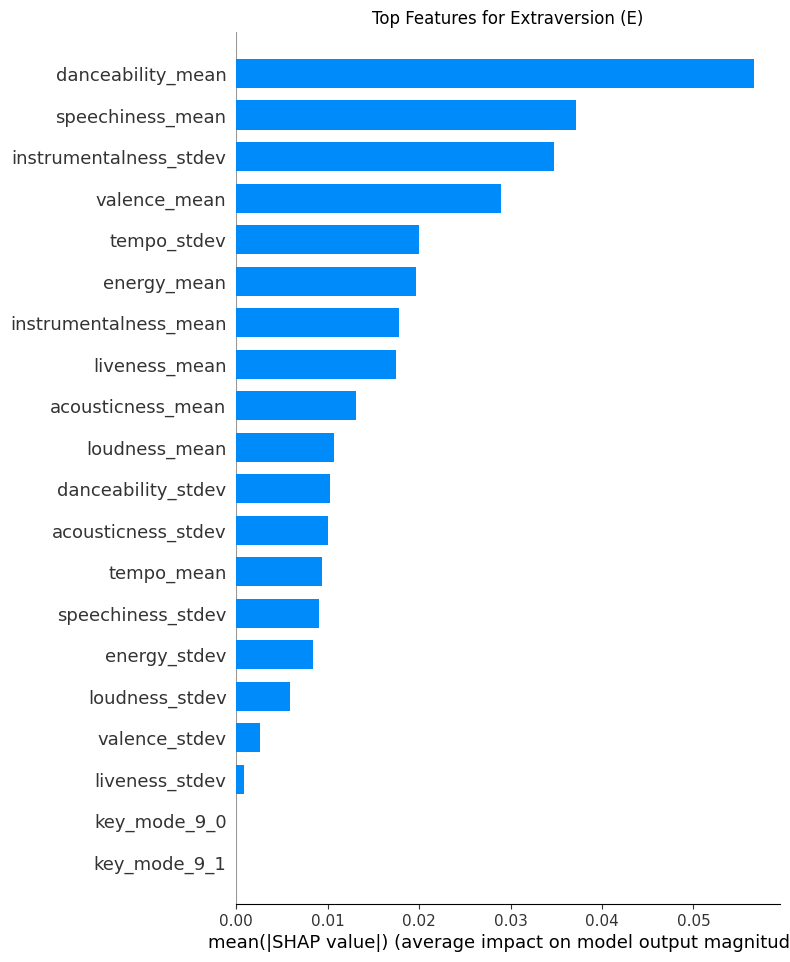


📊 Feature Impact for: Sensing/Intuition (S)


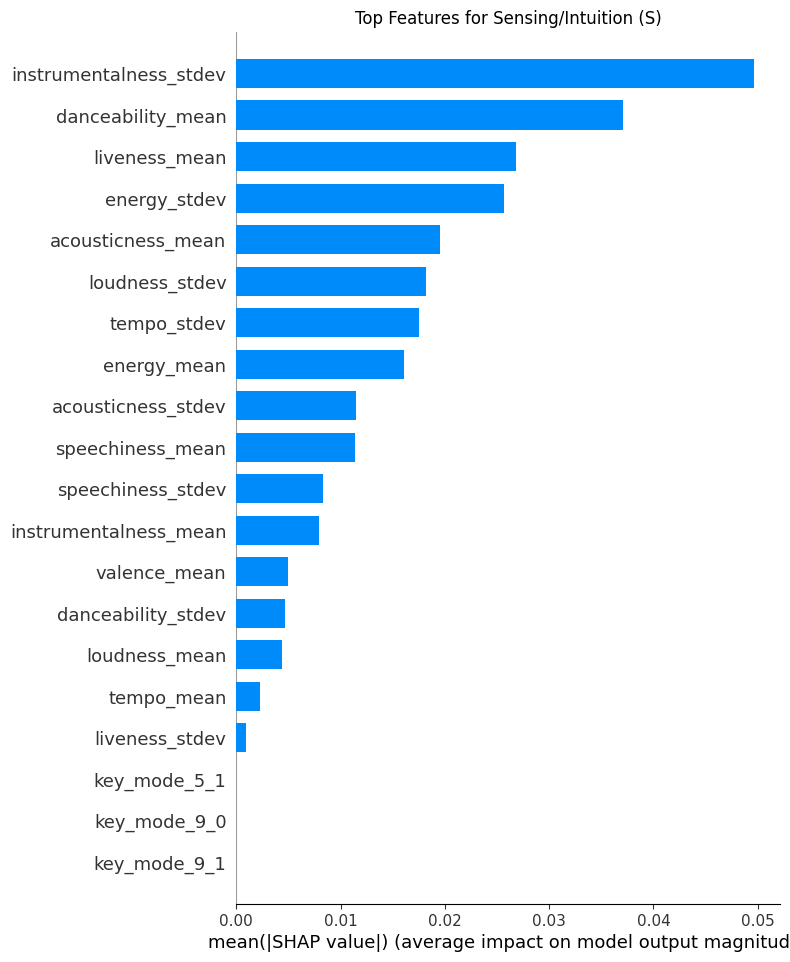


📊 Feature Impact for: Thinking (T)


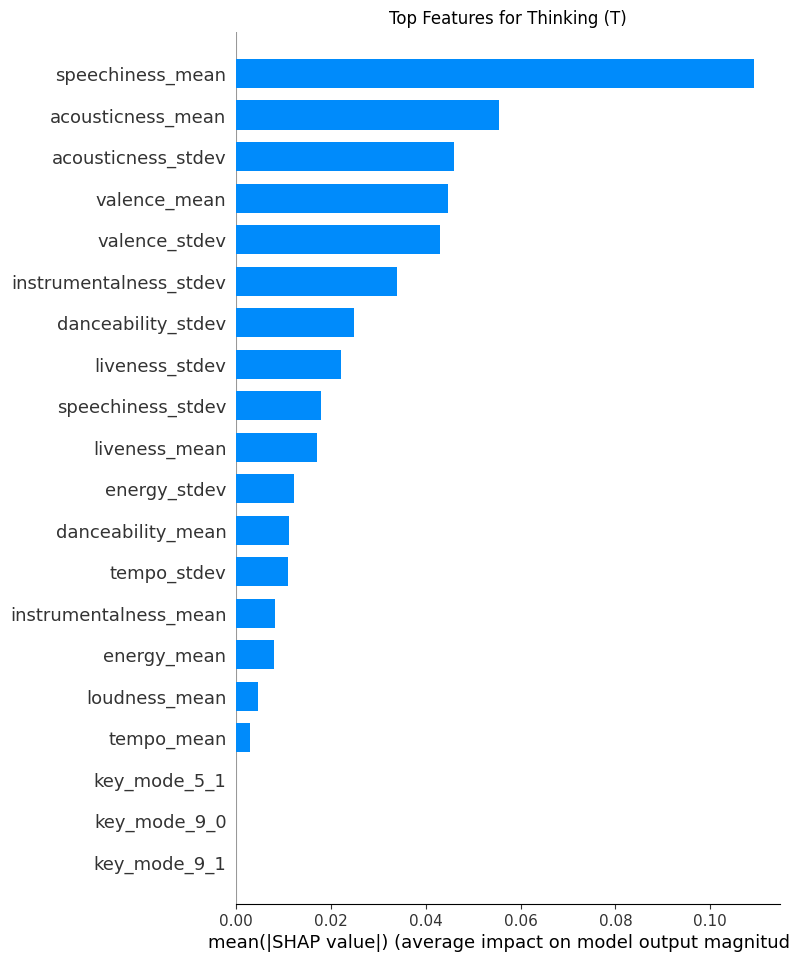


📊 Feature Impact for: Judging (J)


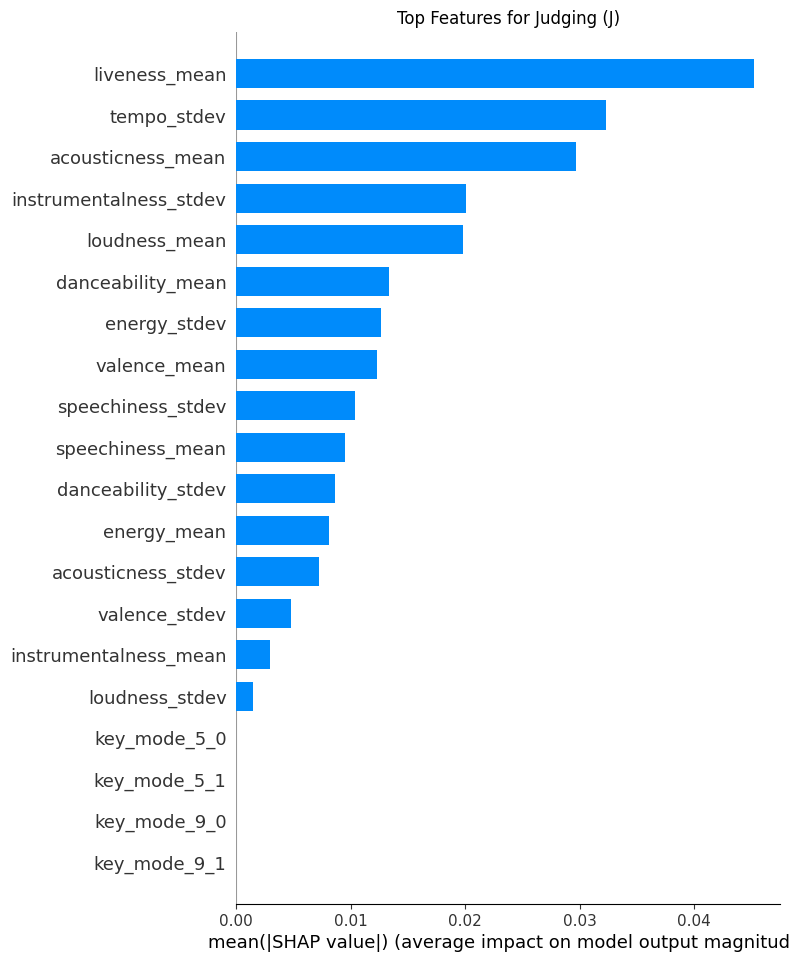

MBTINetwork(
  (music_encoder): AutoencoderEncoder(
    (encoder): Sequential(
      (0): Linear(in_features=42, out_features=128, bias=True)
      (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Dropout(p=0.3, inplace=False)
      (4): Linear(in_features=128, out_features=64, bias=True)
      (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (6): ReLU()
      (7): Linear(in_features=64, out_features=16, bias=True)
    )
  )
  (classifier): Sequential(
    (0): Linear(in_features=16, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Linear(in_features=32, out_features=4, bias=True)
  )
)

In [18]:
# 12 - SHAP explainability

import shap

model.eval()
model.to("cpu")

feature_names_list = feature_cols
background = X_train[:50].numpy()
test_samples = X_test[:5].numpy()

def predict_proba_cpu(x):
    with torch.no_grad():
        x_tensor = torch.tensor(x, dtype=torch.float32)
        return torch.sigmoid(model(x_tensor)).numpy()

print("Initializing KernelExplainer...")
explainer = shap.KernelExplainer(predict_proba_cpu, background)
shap_values = explainer.shap_values(test_samples)

dim_names_shap = ["Extraversion (E)", "Sensing/Intuition (S)", "Thinking (T)", "Judging (J)"]

is_3d = isinstance(shap_values, np.ndarray) and len(shap_values.shape) == 3

for i, name in enumerate(dim_names_shap):
    print(f"\n📊 Feature Impact for: {name}")
    current_shap = shap_values[:, :, i] if is_3d else shap_values[i]

    plt.figure(figsize=(10, 6))
    shap.summary_plot(
        current_shap,
        test_samples,
        feature_names=feature_names_list,
        plot_type="bar",
        show=False
    )
    plt.title(f"Top Features for {name}")
    plt.show()

model.to(device)
